# DS5230 Final Exam Spring 2025

## Problem 1: Clustering Noisy Images [100 points]

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy.stats import entropy
from evaluate import evaluate
import importlib
import sys
import os

In [16]:
data = pd.read_csv("C:/Users/prani/Downloads/exam_2025S_1/exam_2025S/pb1data_XW_8358.txt", header=None)

In [17]:
print(data.head())
print(data.shape)

   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0    0   53   40  119   95   66    4   56  101   52  ...   13   86  136    9   
1    0   42  100   31  126   79  135   84   22   69  ...   13   68   35   41   
2    0   60   10   16  115   73  124    1   25   62  ...   19   77   25   82   
3    0  125   76   87   48  101   48   74   11   51  ...  121  108   25   97   
4    0   24   48  136   84  141   79   82   28   89  ...   88   69  141  129   

   779  780  781  782  783  784  
0   70   83   60   53   17   88  
1  121   51  122   38   36   78  
2   18  116   82   76   61   28  
3   30   32  131   34   50  125  
4   48   37   67   81  108  122  

[5 rows x 785 columns]
(8358, 785)


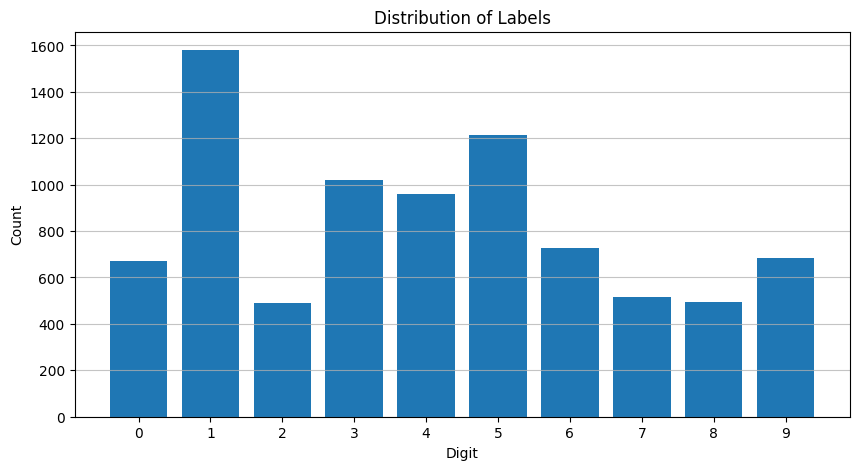

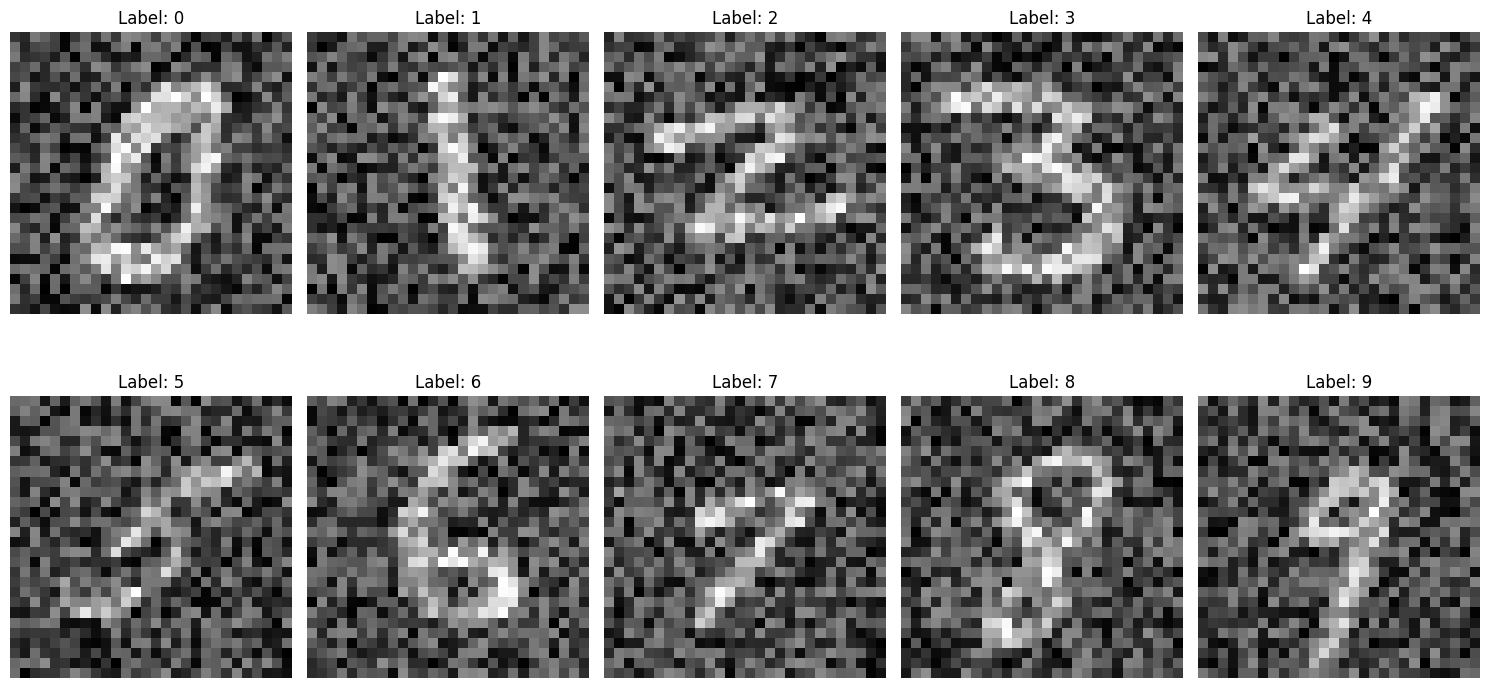

In [18]:
y = data.iloc[:, 0].values 
X = data.iloc[:, 1:].values  

unique_labels, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(unique_labels, counts)
plt.title('Distribution of Labels')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(unique_labels)
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    digit_idx = np.where(y == i)[0][0]
    img = X[digit_idx].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f'Label: {i}')
    plt.axis('off')
plt.tight_layout()
plt.show()

### Feature Extraction using PCA

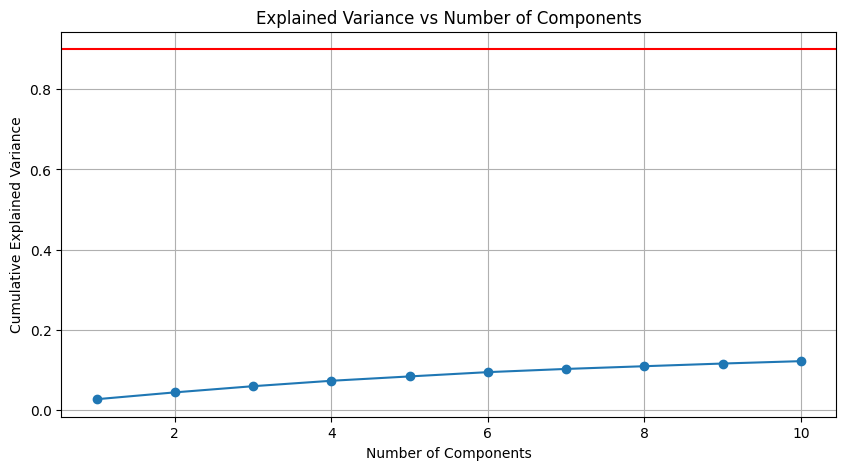

Total variance explained by 10 components: 0.1217


In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_components = 10
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 5))
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.plot(range(1, n_components + 1), cumulative_variance, marker='o')
plt.axhline(y=0.9, color='r', linestyle='-')
plt.grid(True)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.show()

print(f"Total variance explained by {n_components} components: {cumulative_variance[-1]:.4f}")

### K-Means Clustering

In [37]:
np.random.seed(42)
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=8, n_init='auto')
cluster_labels = kmeans.fit_predict(X)

print(f"K-Means clustering completed with {n_clusters} clusters.")

K-Means clustering completed with 10 clusters.


KNN Accuracy: 0.9862


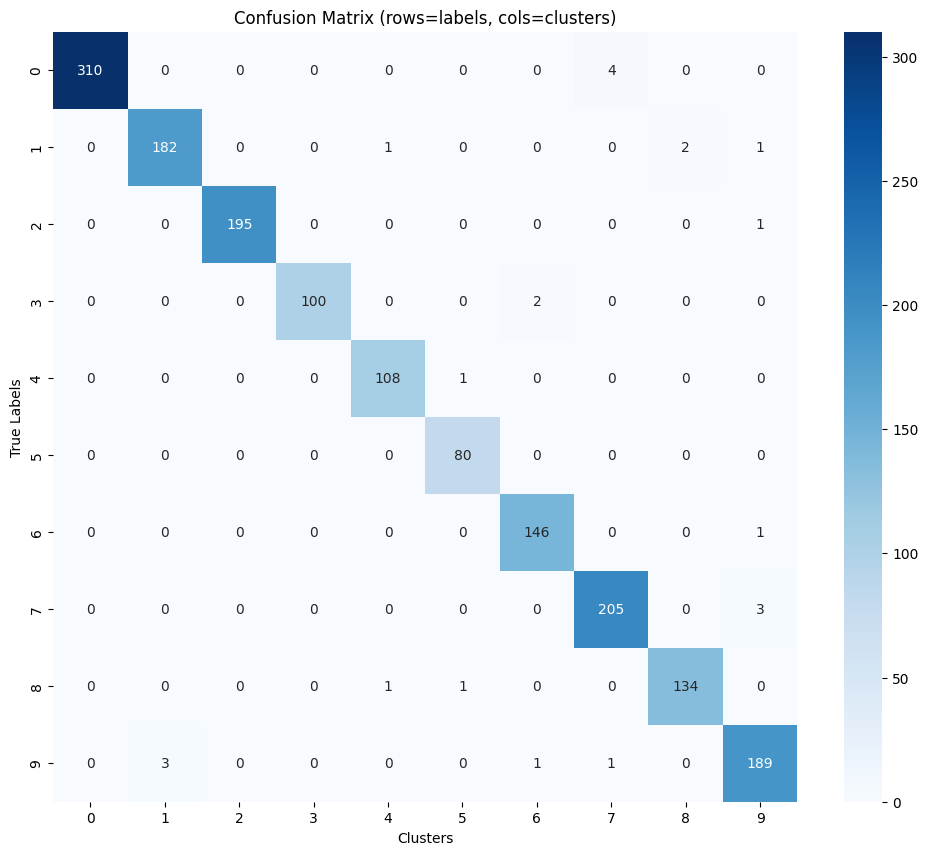

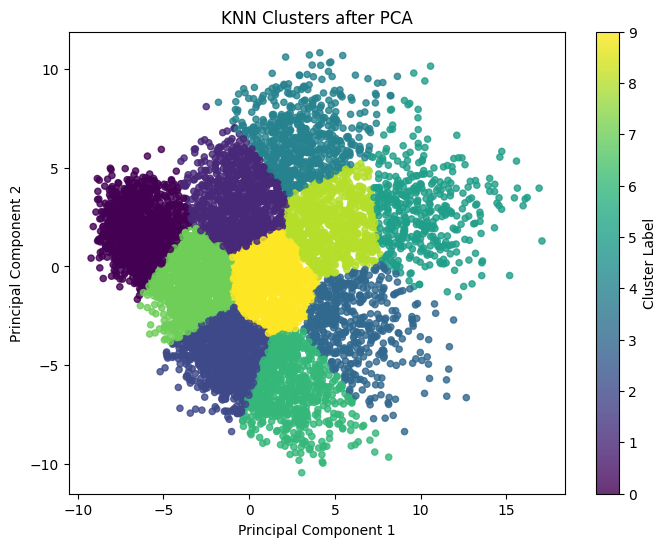

In [ ]:
# I have delibratly reduced the number of components to 2 for visualization purposes
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix 

n_components_pca = 2
pca = PCA(n_components=n_components_pca)
X_pca = pca.fit_transform(X_scaled) 
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=8, n_init='auto')
cluster_labels = kmeans.fit_predict(X_pca) 

X_train, X_test, y_train, y_test = train_test_split(X_pca, cluster_labels, test_size=0.2, random_state=42)
n_neighbors = 5
knn = KNeighborsClassifier(n_neighbors=n_neighbors)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy:.4f}")
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (rows=labels, cols=clusters)')
plt.xlabel('Clusters')
plt.ylabel('True Labels')
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=20, alpha=0.8) 
plt.title('KNN Clusters after PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

### Evaluation

Class Entropies: [1.293 1.096 1.682 1.845 1.601 2.157 1.214 1.515 2.6   1.496]
Cluster Entropies: [1.208 1.866 1.045 1.962 2.094 0.617 1.088 1.191 1.623 1.949]
Weighted average entropies: [1.607 1.545], (avg: 1.576)


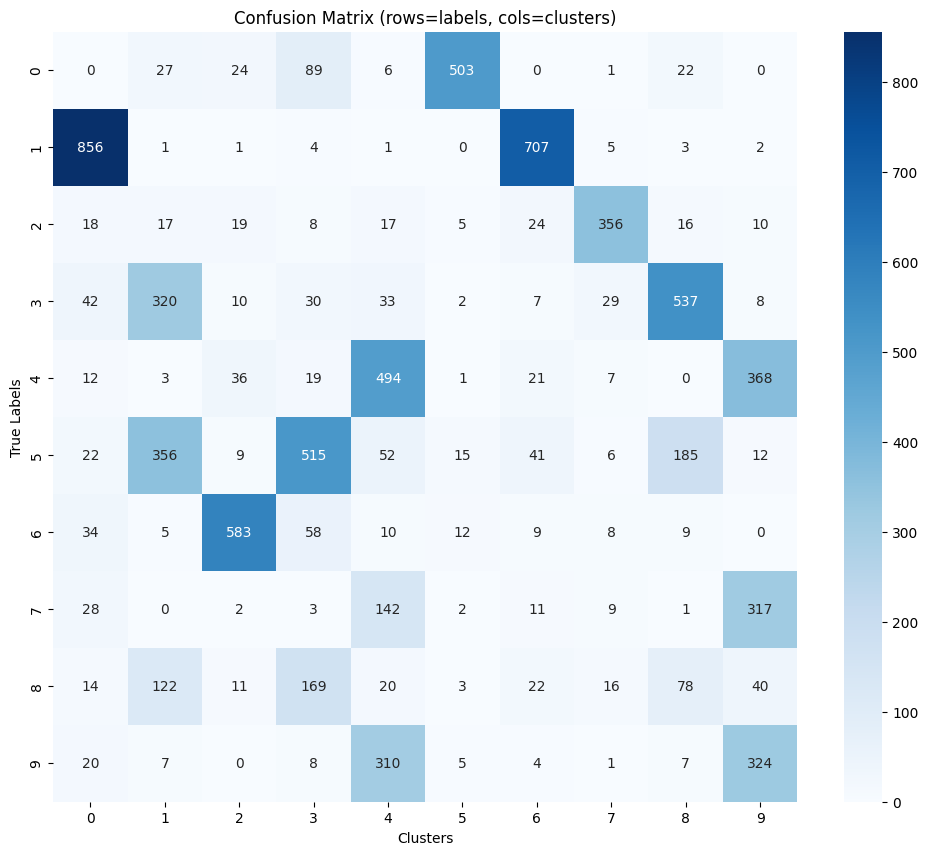

In [40]:
conf_matrix, entropies = evaluate(y, cluster_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (rows=labels, cols=clusters)')
plt.xlabel('Clusters')
plt.ylabel('True Labels')
plt.show()

unique_labels, label_counts = np.unique(y, return_counts=True)
unique_clusters, cluster_counts = np.unique(cluster_labels, return_counts=True)

row_entropies = np.zeros(len(unique_labels))
col_entropies = np.zeros(len(unique_clusters))

for i, label in enumerate(unique_labels):
    dist = conf_matrix[i] / np.sum(conf_matrix[i])
    row_entropies[i] = entropy(dist, base=2)

for j, cluster in enumerate(unique_clusters):
    dist = conf_matrix[:, j] / np.sum(conf_matrix[:, j])
    col_entropies[j] = entropy(dist, base=2)

## Problem 2: Auction House Bidding Analysis [100 points]

### Part A: Theoretical Derivation of Bid Distribution

Auction data loaded successfully with 10000 days recorded.


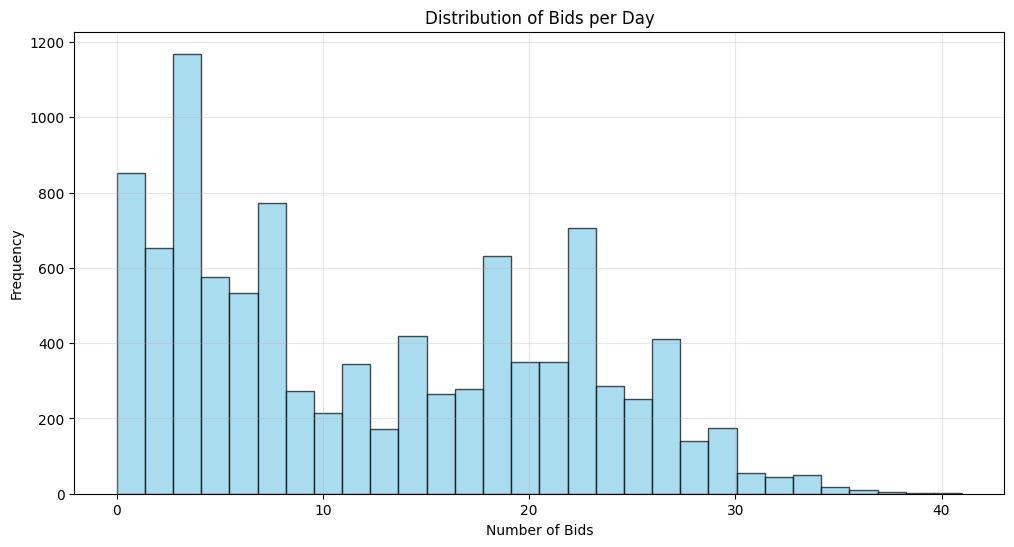

In [8]:
try:
    bid_data = pd.read_csv("C:/Users/prani/Downloads/exam_2025S_1/exam_2025S/pb2data_D.txt", header=None)
    bids = bid_data.iloc[:, 0].values 
    print(f"Auction data loaded successfully with {len(bids)} days recorded.")
    
    plt.figure(figsize=(12, 6))
    plt.hist(bids, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Distribution of Bids per Day')
    plt.xlabel('Number of Bids')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()
except FileNotFoundError:
    print("Error: Auction data file not found. Please ensure 'pb2data_D.txt' is in the correct location.")
    bids = None

The Problem: We want to know how many bids we'll get in a day at the auction.

Assumptions:
- Bids come randomly, like a random stream.
- The waiting time between bids is unpredictable, but follows a pattern (exponential distribution).
- Bids come at an average rate (λ, the bidding rate).

The Answer: The number of bids we get in a day will follow a Poisson distribution with the parameter λ (the average bidding rate).
Why Poisson? Because the Poisson distribution perfectly describes the number of events (bids) in a fixed time period (a day) when:
- Events happen at a constant rate.
- Events happen independently.

### Part B: Implementation of EM Algorithm for Mixture of Poisson Distributions

In [9]:
def poisson_pmf(k, lamb):
    return np.exp(-lamb) * (lamb ** k) / np.math.factorial(k)

def em_poisson_mixture(data, n_components=4, max_iter=100, tol=1e-6):
    n_samples = len(data)
    
    lambdas = np.random.uniform(1, 25, n_components)
    weights = np.ones(n_components) / n_components
    
    responsibilities = np.zeros((n_samples, n_components))
    
    log_likelihood = -np.inf
    
    for iteration in range(max_iter):
        for i in range(n_components):
            for j, x in enumerate(data):
                responsibilities[j, i] = weights[i] * poisson_pmf(x, lambdas[i])
        
        row_sums = responsibilities.sum(axis=1, keepdims=True)
        responsibilities = responsibilities / row_sums
        
        weights = responsibilities.sum(axis=0) / n_samples
        
        for i in range(n_components):
            lambdas[i] = np.sum(responsibilities[:, i] * data) / np.sum(responsibilities[:, i])
        
        new_log_likelihood = 0
        for j, x in enumerate(data):
            new_log_likelihood += np.log(sum(weights[i] * poisson_pmf(x, lambdas[i]) for i in range(n_components)))
        
        if abs(new_log_likelihood - log_likelihood) < tol:
            print(f"Converged after {iteration+1} iterations.")
            break
            
        log_likelihood = new_log_likelihood
        
        if (iteration + 1) % 10 == 0:
            print(f"Iteration {iteration+1}, log-likelihood: {log_likelihood:.6f}")
    
    idx = np.argsort(lambdas)
    lambdas = lambdas[idx]
    weights = weights[idx]
    responsibilities = responsibilities[:, idx]
    
    return lambdas, weights, responsibilities

C:\Users\prani\AppData\Local\Temp\ipykernel_29944\2487393444.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return np.exp(-lamb) * (lamb ** k) / np.math.factorial(k)


Iteration 10, log-likelihood: -34211.189637
Iteration 20, log-likelihood: -34014.780832
Iteration 30, log-likelihood: -33918.855913
Iteration 40, log-likelihood: -33877.459959
Iteration 50, log-likelihood: -33864.314792
Iteration 60, log-likelihood: -33860.282991
Iteration 70, log-likelihood: -33858.568627
Iteration 80, log-likelihood: -33857.403245
Iteration 90, log-likelihood: -33856.378128
Iteration 100, log-likelihood: -33855.406846

Estimated λ-s: [ 2.06  6.39 17.35 23.01]
Estimated #days: [2071 3084 1919 2926]


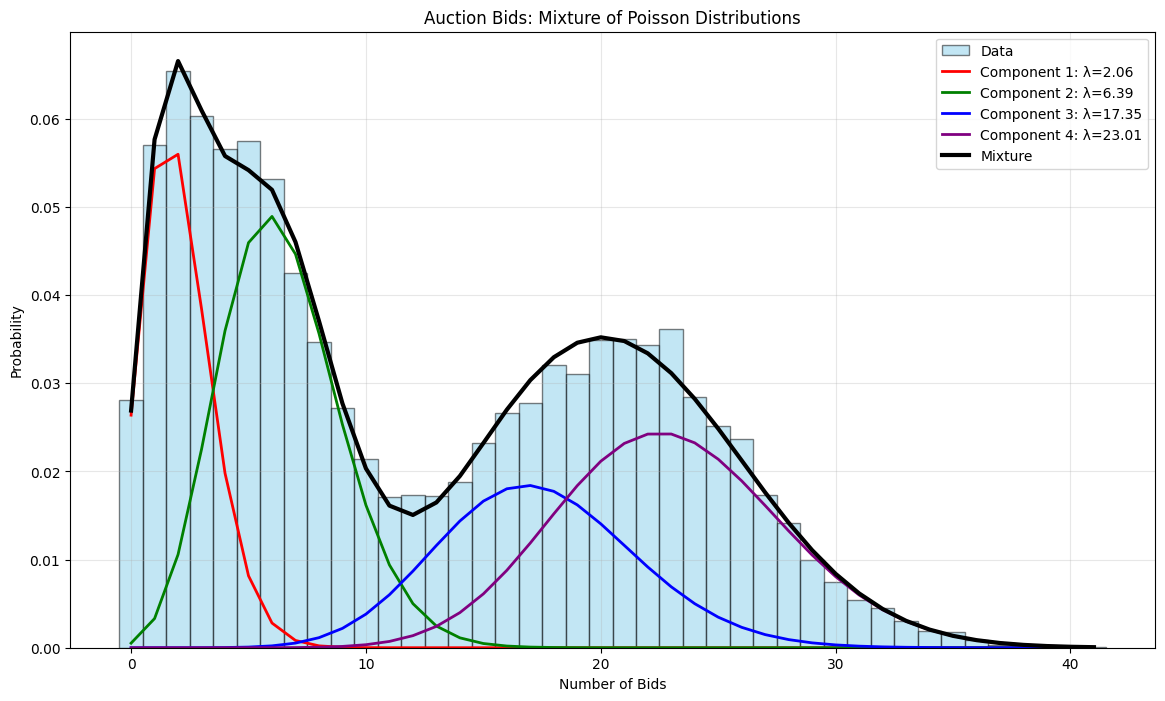

In [10]:
np.random.seed(42)

lambdas, weights, responsibilities = em_poisson_mixture(bids)

n_days_per_class = weights * len(bids)

print("\nEstimated λ-s:", lambdas.round(2))
print("Estimated #days:", n_days_per_class.round(0).astype(int))

plt.figure(figsize=(14, 8))

bins = np.arange(0, max(bids) + 2) - 0.5
plt.hist(bids, bins=bins, alpha=0.5, density=True, color='skyblue', edgecolor='black', label='Data')

x = np.arange(0, max(bids) + 1)

colors = ['red', 'green', 'blue', 'purple']
for i in range(len(lambdas)):
    y = weights[i] * np.array([poisson_pmf(k, lambdas[i]) for k in x])
    plt.plot(x, y, color=colors[i], lw=2, label=f'Component {i+1}: λ={lambdas[i]:.2f}')

y_mixture = np.zeros_like(x, dtype=float)
for i in range(len(lambdas)):
    y_mixture += weights[i] * np.array([poisson_pmf(k, lambdas[i]) for k in x])
plt.plot(x, y_mixture, 'k-', lw=3, label='Mixture')

plt.title('Auction Bids: Mixture of Poisson Distributions')
plt.xlabel('Number of Bids')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()